In [ ]:
# Evaluating NEX-GDDP-CMIP6 Rainfall Projections in Eritrea’s Agricultural Heartlands
# Authors: Tesfalem W. Ghebretnsae, Elsayed S. Mohamed, Umar Joseph James
# This notebook reproduces the analysis and results presented in the study.

In [ ]:
### Script One ###
#### AEZ ZONAL LEVEL ANALYSIS for Historical Period #####


import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import os

# 1. SETUP
input_folder = '/content/AEZ_RAW'
output_folder = '/content/ZONAL_OUTPUTS_A'
if not os.path.exists(output_folder): os.makedirs(output_folder)

zones = {'Arid_Lowland': 'CMIP6_34Models_Verified_Arid_Lowland.csv',
         'Moist_Highland': 'CMIP6_34Models_Verified_Moist_Highland.csv',
         'Moist_Lowland': 'CMIP6_34Models_Verified_Moist_Lowland.csv'}

# 2. THE PERFECT ENGINE ( Definition of Metrics)
def calculate_perfect_metrics(obs, sim):
    mean_o, mean_s = np.mean(obs), np.mean(sim)
    std_o, std_s = np.std(obs), np.std(sim)
    r, _ = pearsonr(obs, sim)
    nsd = std_s / std_o
    crmsd = np.sqrt(np.mean(((sim - mean_s) - (obs - mean_o))**2))
    rmse = np.sqrt(np.mean((sim - obs)**2))
    mb = mean_s - mean_o
    nrmse = rmse / (np.max(obs) - np.min(obs)) if (np.max(obs) - np.min(obs)) != 0 else 0

    # TSS: Exact as per your methodology text (R0 = 1)
    tss = (4 * (1 + r)) / ((nsd + (1/nsd))**2 * (1 + 1.0))

    # IVS: Updated to the Standard 0-1 stable version
    ivs = (nsd - 1)**2

    return [r, nsd, crmsd, rmse, mb, nrmse, tss, ivs]

# 3. EXECUTION
for zone_name, file_name in zones.items():
    file_path = os.path.join(input_folder, file_name)
    if not os.path.exists(file_path): continue
    df = pd.read_csv(file_path).dropna(subset=['Precip_mm'])
    df_avg = df.groupby(['Model', 'Year', 'Month'])['Precip_mm'].mean().reset_index()

    obs_df = df_avg[df_avg['Model'] == 'CHIRPS'].sort_values(['Year', 'Month'])
    results = []
    for m in sorted([x for x in df_avg['Model'].unique() if x != 'CHIRPS']):
        sim_df = df_avg[df_avg['Model'] == m].sort_values(['Year', 'Month'])
        merged = pd.merge(obs_df, sim_df, on=['Year', 'Month'], suffixes=('_o', '_s'))
        results.append([m] + calculate_perfect_metrics(merged['Precip_mm_o'].values, merged['Precip_mm_s'].values))

    perf_df = pd.DataFrame(results, columns=['Model', 'r', 'NSD', 'CRMSD', 'RMSE', 'MB', 'NRMSE', 'TSS', 'IVS'])
    perf_df.to_csv(f"{output_folder}/Table1_Metrics_{zone_name}.csv", index=False)

    # CRI RANKING (0-1 Score based on 8 Metrics)
    s = perf_df.copy()
    s['s_r'] = (s['r']-s['r'].min())/(s['r'].max()-s['r'].min())
    s['s_tss'] = (s['TSS']-s['TSS'].min())/(s['TSS'].max()-s['TSS'].min())
    s['s_nsd'] = 1 - abs(1-s['NSD'])/abs(1-s['NSD']).max()
    s['s_mb'] = 1 - (abs(s['MB'])-abs(s['MB']).min())/(abs(s['MB']).max()-abs(s['MB']).min())
    for c in ['CRMSD', 'RMSE', 'NRMSE', 'IVS']:
        s[f's_{c.lower()}'] = 1 - (s[c]-s[c].min())/(s[c].max()-s[c].min())

    rank_df = pd.DataFrame({'Model': s['Model'], 'CRI': s[['s_r','s_tss','s_nsd','s_mb','s_crmsd','s_rmse','s_nrmse','s_ivs']].mean(axis=1)})
    rank_df = rank_df.sort_values('CRI', ascending=False).reset_index(drop=True)
    rank_df['Rank'] = rank_df.index + 1
    rank_df.to_csv(f"{output_folder}/Table2_CRI_{zone_name}.csv", index=False)

print("✅ Zonal Outputs Finalized.")

✅ Zonal Outputs Finalized.


In [ ]:
### Script Two ###
### NATIONAL LEVEL ANALYSIS OF HISTORICAL DATA #####

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import os

# 1. SETUP FOLDERS
input_file = '/content/NATIONAL_RAW/CMIP6_34Models_Verified_Rainfall.csv'
output_folder = '/content/NATIONAL_OUTPUTS_A'
if not os.path.exists(output_folder): os.makedirs(output_folder)

# 2. THE PERFECT ENGINE (Definition of Metrics)
def calculate_perfect_metrics(obs, sim):
    mean_o, mean_s = np.mean(obs), np.mean(sim)
    std_o, std_s = np.std(obs), np.std(sim)

    # 1. Pearson Correlation (r)
    r, _ = pearsonr(obs, sim)

    # 2. Normalized Standard Deviation (NSD)
    nsd = std_s / std_o

    # 3. Centered Root Mean Square Difference (CRMSD)
    crmsd = np.sqrt(np.mean(((sim - mean_s) - (obs - mean_o))**2))

    # 4. Root Mean Square Error (RMSE)
    rmse = np.sqrt(np.mean((sim - obs)**2))

    # 5. Mean Bias (MB)
    mb = mean_s - mean_o

    # 6. Normalized RMSE (NRMSE) - Normalized by Range
    nrmse = rmse / (np.max(obs) - np.min(obs)) if (np.max(obs) - np.min(obs)) != 0 else 0

    # 7. Taylor Skill Score (TSS) - Exact as per your methodology text (R0 = 1)
    tss = (4 * (1 + r)) / ((nsd + (1/nsd))**2 * (1 + 1.0))

    # 8. Interannual Variability Score (IVS) - Standard 0-1 stable version
    ivs = (nsd - 1)**2

    return [r, nsd, crmsd, rmse, mb, nrmse, tss, ivs]

# 3. DATA PROCESSING
print("Loading National Data...")
df = pd.read_csv(input_file).dropna(subset=['Precip_mm'])

# Grouping by mean to get spatial average depth (Ensures consistency with Zonal)
df_avg = df.groupby(['Model', 'Year', 'Month'])['Precip_mm'].mean().reset_index()

obs_series = df_avg[df_avg['Model'] == 'CHIRPS'].sort_values(['Year', 'Month'])
models = sorted([m for m in df_avg['Model'].unique() if m != 'CHIRPS'])

print(f"Processing {len(models)} models...")
results = []
for m in models:
    sim_series = df_avg[df_avg['Model'] == m].sort_values(['Year', 'Month'])
    merged = pd.merge(obs_series, sim_series, on=['Year', 'Month'], suffixes=('_o', '_s'))

    if len(merged) > 1:
        res = calculate_perfect_metrics(merged['Precip_mm_o'].values, merged['Precip_mm_s'].values)
        results.append([m] + res)

# 4. SAVE TABLE 1: PERFORMANCE METRICS
perf_df = pd.DataFrame(results, columns=['Model', 'r', 'NSD', 'CRMSD', 'RMSE', 'MB', 'NRMSE', 'TSS', 'IVS'])
perf_df.to_csv(f'{output_folder}/National_Table1_Metrics.csv', index=False)

# 5. SAVE TABLE 2: CRI RANKING (0-1 Score based on 8 Metrics)
s = perf_df.copy()

# Higher is better
s['s_r'] = (s['r'] - s['r'].min()) / (s['r'].max() - s['r'].min())
s['s_tss'] = (s['TSS'] - s['TSS'].min()) / (s['TSS'].max() - s['TSS'].min())

# Closer to 1 is better (NSD)
s['s_nsd'] = 1 - abs(1 - s['NSD']) / abs(1 - s['NSD']).max()

# Closer to 0 is better (MB)
s['s_mb'] = 1 - (abs(s['MB']) - abs(s['MB']).min()) / (abs(s['MB']).max() - abs(s['MB']).min())

# Lower is better (Errors and IVS)
for col in ['CRMSD', 'RMSE', 'NRMSE', 'IVS']:
    s[f's_{col.lower()}'] = 1 - (s[col] - s[col].min()) / (s[col].max() - s[col].min())

# Final CRI Average of all 8 normalized components
rank_df = pd.DataFrame({'Model': s['Model'],
                        'CRI': s[['s_r','s_tss','s_nsd','s_mb','s_crmsd','s_rmse','s_nrmse','s_ivs']].mean(axis=1)})

rank_df = rank_df.sort_values('CRI', ascending=False).reset_index(drop=True)
rank_df['Rank'] = rank_df.index + 1

rank_df.to_csv(f'{output_folder}/National_Table2_CRI.csv', index=False)

print(f"✅ National Evaluation Complete. All files saved in {output_folder}")

Loading National Data...
Processing 34 models...
✅ National Evaluation Complete. All files saved in /content/NATIONAL_OUTPUTS_A


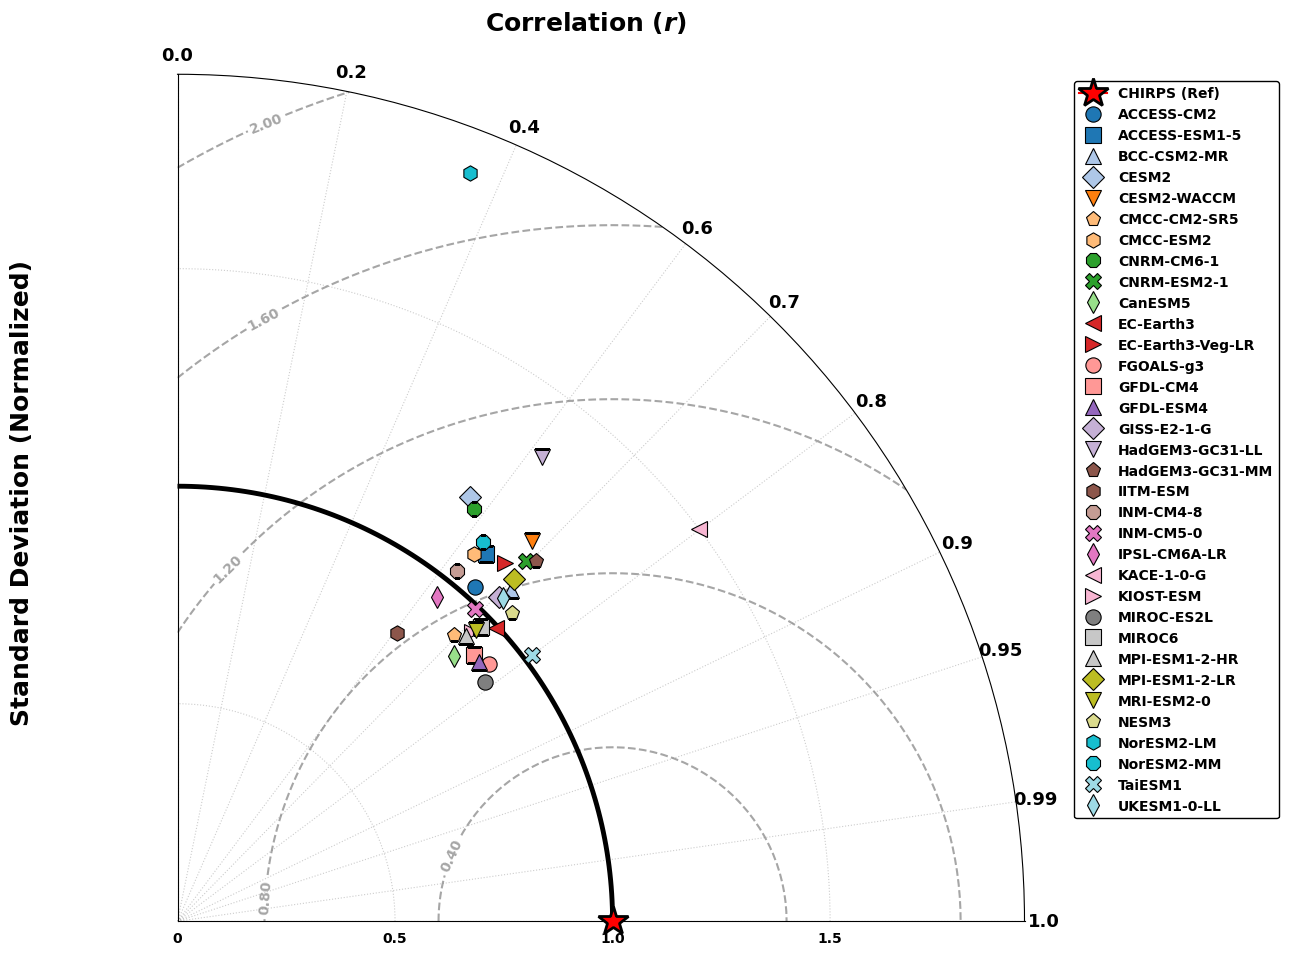

In [ ]:
### Script Three ####
### Taylor Diagram DEsign for National Level ####

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Folders
input_folder = '/content/NATIONAL_OUTPUTS_A'
output_folder = '/content/NATIONAL_OUTPUTS_A'

def plot_national_taylor_final(df, output_path):
    # Global Bold Settings
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"

    fig = plt.figure(figsize=(12, 11), facecolor='white')
    ax = fig.add_subplot(111, projection='polar')

    # First Quadrant Only
    ax.set_thetamin(0)
    ax.set_thetamax(90)

    # Correlation Axis (theta)
    r_ticks = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
    ax.set_xticks(np.arccos(r_ticks))
    ax.set_xticklabels([str(r) for r in r_ticks], fontweight='bold', fontsize=13)

    # Standard Deviation Axis (radial)
    std_limit = max(1.5, df['NSD'].max() + 0.1)
    ax.set_ylim(0, std_limit)
    ax.set_yticks([0, 0.5, 1.0, 1.5])
    ax.set_yticklabels(['0', '0.5', '1.0', '1.5'], fontweight='bold', fontsize=13)

    ax.grid(True, linestyle=':', alpha=0.4, color='gray')

    # CHIRPS Reference Point & Arc
    ax.plot(np.linspace(0, np.pi/2, 100), np.ones(100), color='black', lw=3.5, zorder=4)
    ax.plot(0, 1.0, marker='*', color='red', ms=22, label='CHIRPS (Ref)',
            mec='black', mew=2.0, clip_on=False, zorder=7)

    # Plot Models
    N = len(df)
    cmap = plt.get_cmap('tab20', N)
    markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '8', 'X', 'd', '<', '>']

    for i, row in df.iterrows():
        ax.plot(np.arccos(row['r']), row['NSD'], marker=markers[i % len(markers)],
                ls='', ms=11, label=row['Model'], mfc=cmap(i), mec='black', mew=0.8, zorder=6)

    # CRMSD Contours
    rs, ts = np.meshgrid(np.linspace(0, std_limit, 100), np.linspace(0, np.pi/2, 100))
    rmsd = np.sqrt(1 + rs**2 - 2 * rs * np.cos(ts))
    contours = ax.contour(ts, rs, rmsd, levels=5, colors='gray', linestyles='--', alpha=0.7)
    ax.clabel(contours, inline=1, fontsize=10, fmt='%.2f')

    # Legend
    leg = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10,
                    frameon=True, edgecolor='black', framealpha=1)
    for text in leg.get_texts(): text.set_fontweight('bold')

    # --- AXIS LABELS (No Top Title) ---
    fig.text(0.5, 0.92, 'Correlation ($r$)', ha='center', fontsize=18, fontweight='bold')
    fig.text(0.02, 0.5, 'Standard Deviation (Normalized)', va='center', rotation='vertical', fontsize=18, fontweight='bold')

    plt.savefig(output_path, dpi=650, bbox_inches='tight')
    plt.show()

# Run
file_path = os.path.join(input_folder, "National_Table1_Metrics.csv")
if os.path.exists(file_path):
    df_metrics = pd.read_csv(file_path)
    plot_national_taylor_final(df_metrics, os.path.join(output_folder, "National_Taylor_Final_A.png"))

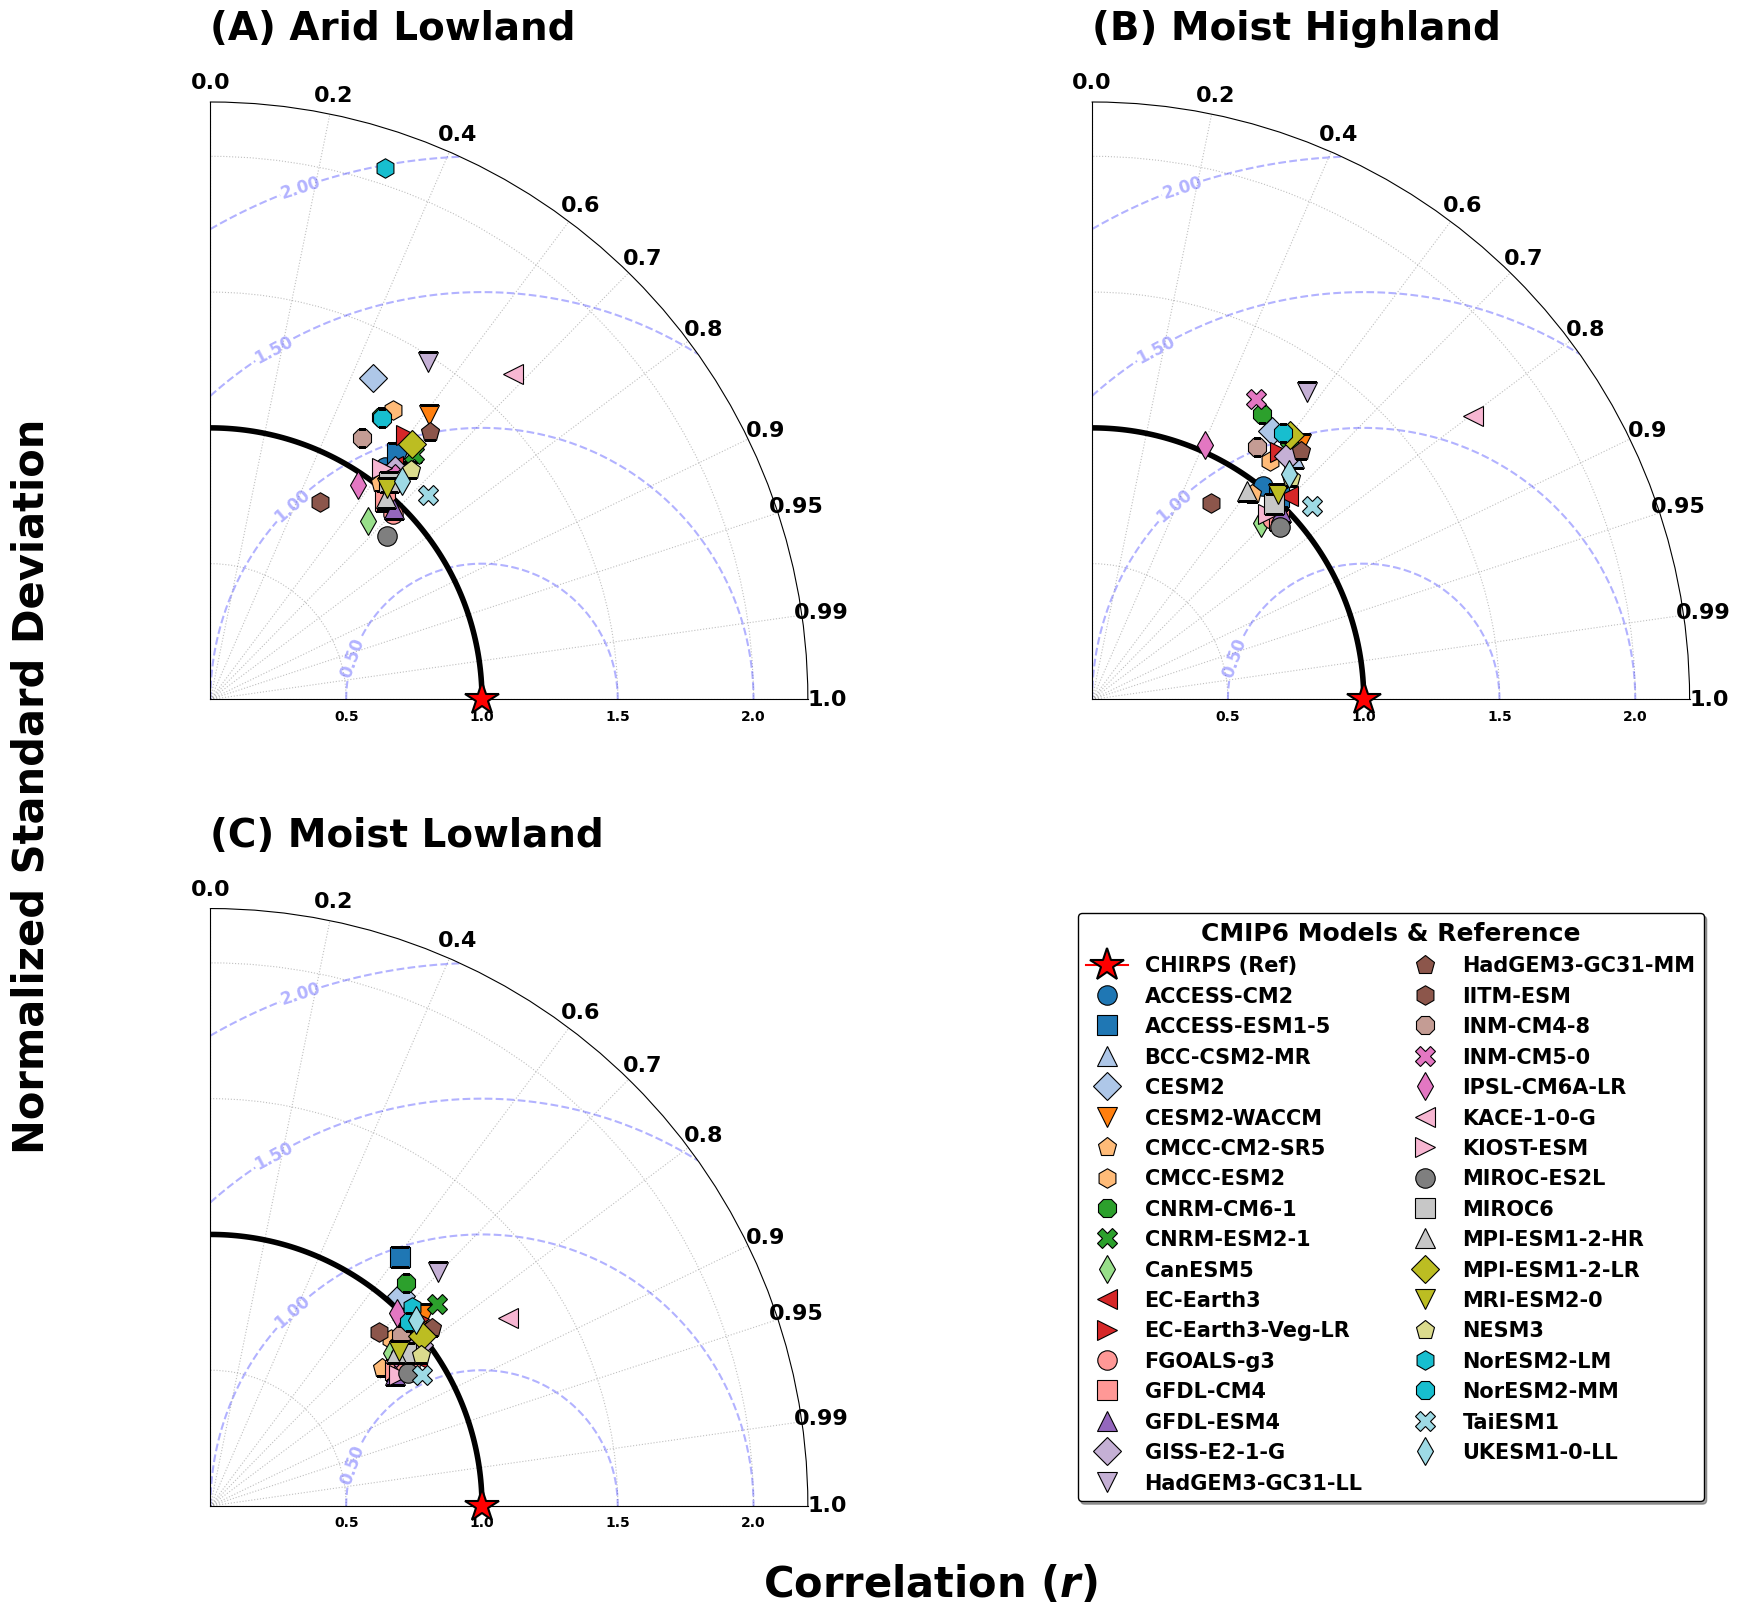

In [ ]:
### Script Four ####
### Taylor Diagram DEsign for AEZ Level ####


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Folders
input_folder = '/content/ZONAL_OUTPUTS_A'
output_folder = '/content/ZONAL_OUTPUTS_A'

# Mapping files to Panels (Using a list of tuples to control grid order)
zones_list = [
    ('Arid_Lowland', 'A'),
    ('Moist_Highland', 'B'),
    ('Moist_Lowland', 'C')
]

def generate_grid_taylor(input_folder, output_path):
    plt.rcParams["font.weight"] = "bold"
    plt.rcParams["axes.labelweight"] = "bold"

    # 1. LARGE SQUARE-ISH CANVAS: 20x18 provides huge space for a 2x2 grid
    fig = plt.figure(figsize=(20, 18), facecolor='white')

    # Store handles and labels for a unified legend
    all_handles = []
    all_labels = []

    for idx, (zone, label) in enumerate(zones_list):
        file_path = os.path.join(input_folder, f"Table1_Metrics_{zone}.csv")
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        # Grid positions: Index 1, 2, 3 (leaving index 4 for legend)
        ax = fig.add_subplot(2, 2, idx + 1, projection='polar')

        # First Quadrant Setup
        ax.set_thetamin(0)
        ax.set_thetamax(90)

        # Correlation Axis
        r_ticks = np.array([0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
        ax.set_xticks(np.arccos(r_ticks))
        ax.set_xticklabels([str(r) for r in r_ticks], fontweight='bold', fontsize=16)

        # Radial Axis (NSD)
        std_limit = 2.2
        ax.set_ylim(0, std_limit)
        ax.set_yticks([0.5, 1.0, 1.5, 2.0])
        ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0'], fontweight='bold', fontsize=16)
        ax.grid(True, linestyle=':', alpha=0.5, color='gray')

        # CHIRPS Reference
        ref_line, = ax.plot(np.linspace(0, np.pi/2, 100), np.ones(100), color='black', lw=4, zorder=4)
        ref_star, = ax.plot(0, 1.0, marker='*', color='red', ms=25, label='CHIRPS (Ref)',
                           mec='black', mew=1.5, clip_on=False, zorder=10)

        # Plot Models
        N = len(df)
        cmap = plt.get_cmap('tab20', N)
        markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '8', 'X', 'd', '<', '>']

        for i, row in df.iterrows():
            m_handle, = ax.plot(np.arccos(row['r']), row['NSD'], marker=markers[i % len(markers)],
                               ls='', ms=14, label=row['Model'], mfc=cmap(i), mec='black', mew=0.8, zorder=8)

            # Collect legend handles only once (from the first plot)
            if idx == 0:
                all_handles.append(m_handle)
                all_labels.append(row['Model'])

        # Add reference handles to the top of the legend list
        if idx == 0:
            all_handles.insert(0, ref_star)
            all_labels.insert(0, 'CHIRPS (Ref)')

        # CRMSD Contours
        rs, ts = np.meshgrid(np.linspace(0, std_limit, 100), np.linspace(0, np.pi/2, 100))
        rmsd = np.sqrt(1 + rs**2 - 2 * rs * np.cos(ts))
        contours = ax.contour(ts, rs, rmsd, levels=4, colors='blue', linestyles='--', alpha=0.3)
        ax.clabel(contours, inline=1, fontsize=12, fmt='%.2f')

        # Panel Title
        ax.set_title(f"({label}) {zone.replace('_', ' ')}", loc='left',
                     fontsize=28, fontweight='bold', pad=45)

    # 2. CREATE THE LEGEND PANEL in the 4th slot (bottom right)
    # Create an empty axis for the legend
    leg_ax = fig.add_subplot(2, 2, 4)
    leg_ax.axis('off') # Hide axes

    # Place the legend in the center of the 4th quadrant
    leg_ax.legend(all_handles, all_labels, loc='center', fontsize=15,
                  ncol=2, frameon=True, edgecolor='black', shadow=True,
                  title="CMIP6 Models & Reference", title_fontsize=18)

    # Global Axis Labels - Adjusted for 2x2 layout
    fig.text(0.5, 0.05, 'Correlation ($r$)', ha='center', fontsize=30, fontweight='bold')
    fig.text(0.04, 0.5, 'Normalized Standard Deviation', va='center', rotation='vertical',
             fontsize=30, fontweight='bold')

    # Adjust spacing to ensure nothing overlaps
    plt.subplots_adjust(wspace=0.3, hspace=0.35, bottom=0.1, left=0.12, right=0.9)

    plt.savefig(output_path, dpi=600, bbox_inches='tight')
    plt.show()

# Execute
generate_grid_taylor(input_folder, os.path.join(output_folder, "Figure3_2x2_Taylor.png"))

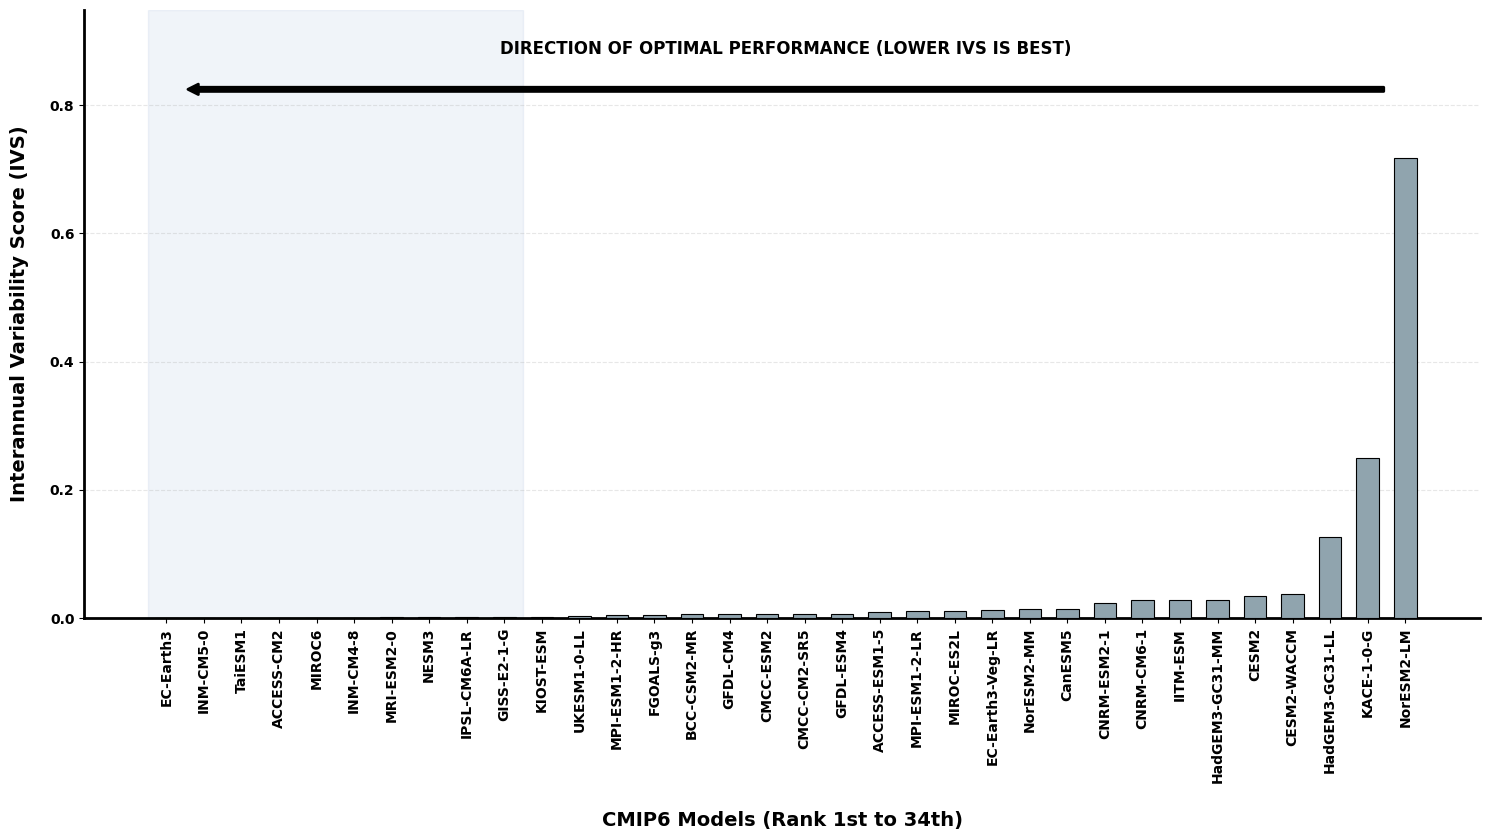

✅ High-Contrast IVS Gradient Plot with Arrow saved to /content/NATIONAL_OUTPUTS_A/National_IVS_Final_Gradient_Arrow.png


In [ ]:
### Script Five ####
### IVS Design and Analysis ####

import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyArrowPatch

# 1. Setup Folders
input_file = '/content/NATIONAL_OUTPUTS_A/National_Table1_Metrics.csv'
output_path = '/content/NATIONAL_OUTPUTS_A/National_IVS_Final_Gradient_Arrow.png'
if not os.path.exists('/content/NATIONAL_OUTPUTS_A'):
    os.makedirs('/content/NATIONAL_OUTPUTS_A')

# 2. Load and Sort (Lower IVS is better - Elite at the beginning)
df = pd.read_csv(input_file)
df_sorted = df.sort_values('IVS', ascending=True).reset_index(drop=True)

# 3. Create Plot (A high-density bar concept)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
fig, ax = plt.subplots(figsize=(15, 8.5), facecolor='white')

# Define Colors (Midnight Gradient)
# Top 10 are Deep Navy Blue, the rest are sleek Slate Grey
colors = ['#0D47A1' if i < 10 else '#90A4AE' for i in range(len(df_sorted))]

# 4. Draw the "Tinny" Bars (Thin for elegant comparison of 34 models)
bars = ax.bar(df_sorted.index, df_sorted['IVS'], color=colors,
              edgecolor='black', linewidth=0.8, width=0.6, zorder=3)

# --- 5. THE DIRECTIONAL ARROW (Corrected to show in-line) ---
# Arrow starts over the poor models (higher IVS) and points to the best (lower IVS)
# Position it high above the bars
arrow_y_height = df_sorted['IVS'].max() * 1.15
arrow_start_x = len(df_sorted) - 1.5 # Over the poor models
arrow_end_x = 0.5                  # Over the best models

# Create the FancyArrowPatch and add it explicitly to the axes
arrow = FancyArrowPatch((arrow_start_x, arrow_y_height),
                       (arrow_end_x, arrow_y_height),
                       mutation_scale=15, # Controls the arrow head size
                       color='black', lw=2, zorder=10)
ax.add_patch(arrow)

# 6. BOLD PUBLICATION TEXT FOR CLARITY (Above the Arrow)
# Make sure the font is large enough for peer-review
ax.text((arrow_start_x + arrow_end_x)/2, arrow_y_height * 1.06,
        'DIRECTION OF OPTIMAL PERFORMANCE (LOWER IVS IS BEST)',
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', zorder=11)

# 7. Axis Styling and Cleaning (No Top Title)
ax.set_xticks(df_sorted.index)
# Use a clear rotation and large font for model names
ax.set_xticklabels(df_sorted['Model'], rotation=90, fontweight='bold', fontsize=10)

ax.set_ylabel('Interannual Variability Score (IVS)', fontsize=14, fontweight='bold', labelpad=15)
# Rephrase the X-axis for complete clarity
ax.set_xlabel('CMIP6 Models (Rank 1st to 34th)',
              fontsize=14, fontweight='bold', labelpad=20)

# Cleaning Spines for a minimalist design
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Subgrids for readability
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

# Use a specific shade to highlight the "Elite Top 10" zone
ax.axvspan(-0.5, 9.5, color='#0D47A1', alpha=0.06, zorder=1)

# Ensure the y-axis has a slight pad for the arrow
ax.set_ylim(0, arrow_y_height * 1.15)

plt.tight_layout()
plt.savefig(output_path, dpi=650, bbox_inches='tight')
plt.show()
print(f"✅ High-Contrast IVS Gradient Plot with Arrow saved to {output_path}")

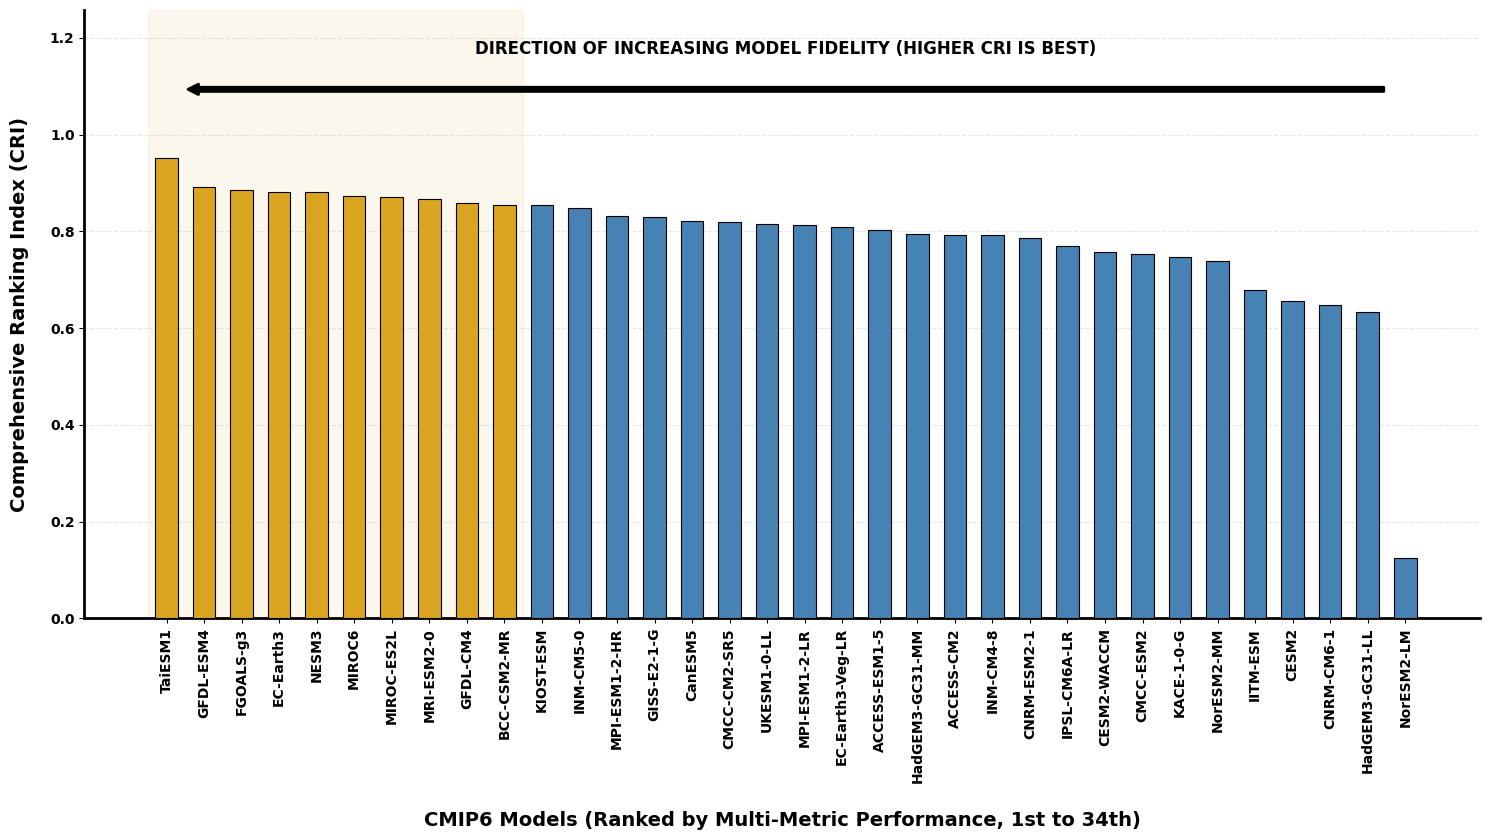

In [ ]:
### Script Six ####
### CRI Evaluation and Rankling Analysis ####

import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyArrowPatch

# 1. Setup
input_file = '/content/NATIONAL_OUTPUTS_A/National_Table2_CRI.csv'
output_path = '/content/NATIONAL_OUTPUTS_A/National_CRI_Final_Skyline_Arrow.png'

# 2. Load and Sort (Higher CRI is better - Rank 1 on the left)
df = pd.read_csv(input_file)
df_sorted = df.sort_values('CRI', ascending=False).reset_index(drop=True)

# 3. Create Plot
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
fig, ax = plt.subplots(figsize=(15, 8.5), facecolor='white')

# Define Colors (Goldenrod for Top 10, Steel Blue for the Field)
colors = ['#DAA520' if i < 10 else '#4682B4' for i in range(len(df_sorted))]

# 4. Draw the "Tinny" Bars
bars = ax.bar(df_sorted.index, df_sorted['CRI'], color=colors,
              edgecolor='black', linewidth=0.8, width=0.6, zorder=3)

# 5. THE DIRECTIONAL ARROW (Points toward the BEST/HIGHEST performers)
# For CRI, the arrow starts at the right (lower values) and points left (higher values)
arrow_y_height = df_sorted['CRI'].max() * 1.15
arrow_start_x = len(df_sorted) - 1.5
arrow_end_x = 0.5

arrow = FancyArrowPatch((arrow_start_x, arrow_y_height),
                       (arrow_end_x, arrow_y_height),
                       mutation_scale=15,
                       color='black', lw=2, zorder=10)
ax.add_patch(arrow)

# 6. BOLD PUBLICATION TEXT (Above the Arrow)
ax.text((arrow_start_x + arrow_end_x)/2, arrow_y_height * 1.06,
        'DIRECTION OF INCREASING MODEL FIDELITY (HIGHER CRI IS BEST)',
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', zorder=11)

# 7. Axis Styling (No Top Title)
ax.set_xticks(df_sorted.index)
ax.set_xticklabels(df_sorted['Model'], rotation=90, fontweight='bold', fontsize=10)

ax.set_ylabel('Comprehensive Ranking Index (CRI)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_xlabel('CMIP6 Models (Ranked by Multi-Metric Performance, 1st to 34th)',
              fontsize=14, fontweight='bold', labelpad=20)

# Cleaning Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Grid and Highlights
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_ylim(0, arrow_y_height * 1.15)

# Subtle highlight for the "Gold Standard" Top 10
ax.axvspan(-0.5, 9.5, color='#DAA520', alpha=0.08, zorder=1)

plt.tight_layout()
plt.savefig(output_path, dpi=650, bbox_inches='tight')
plt.show()

🎨 Creating the Spatial Masterpiece...
✅ Masterpiece saved as CMIP6_Spatial_Masterpiece_600DPI.png


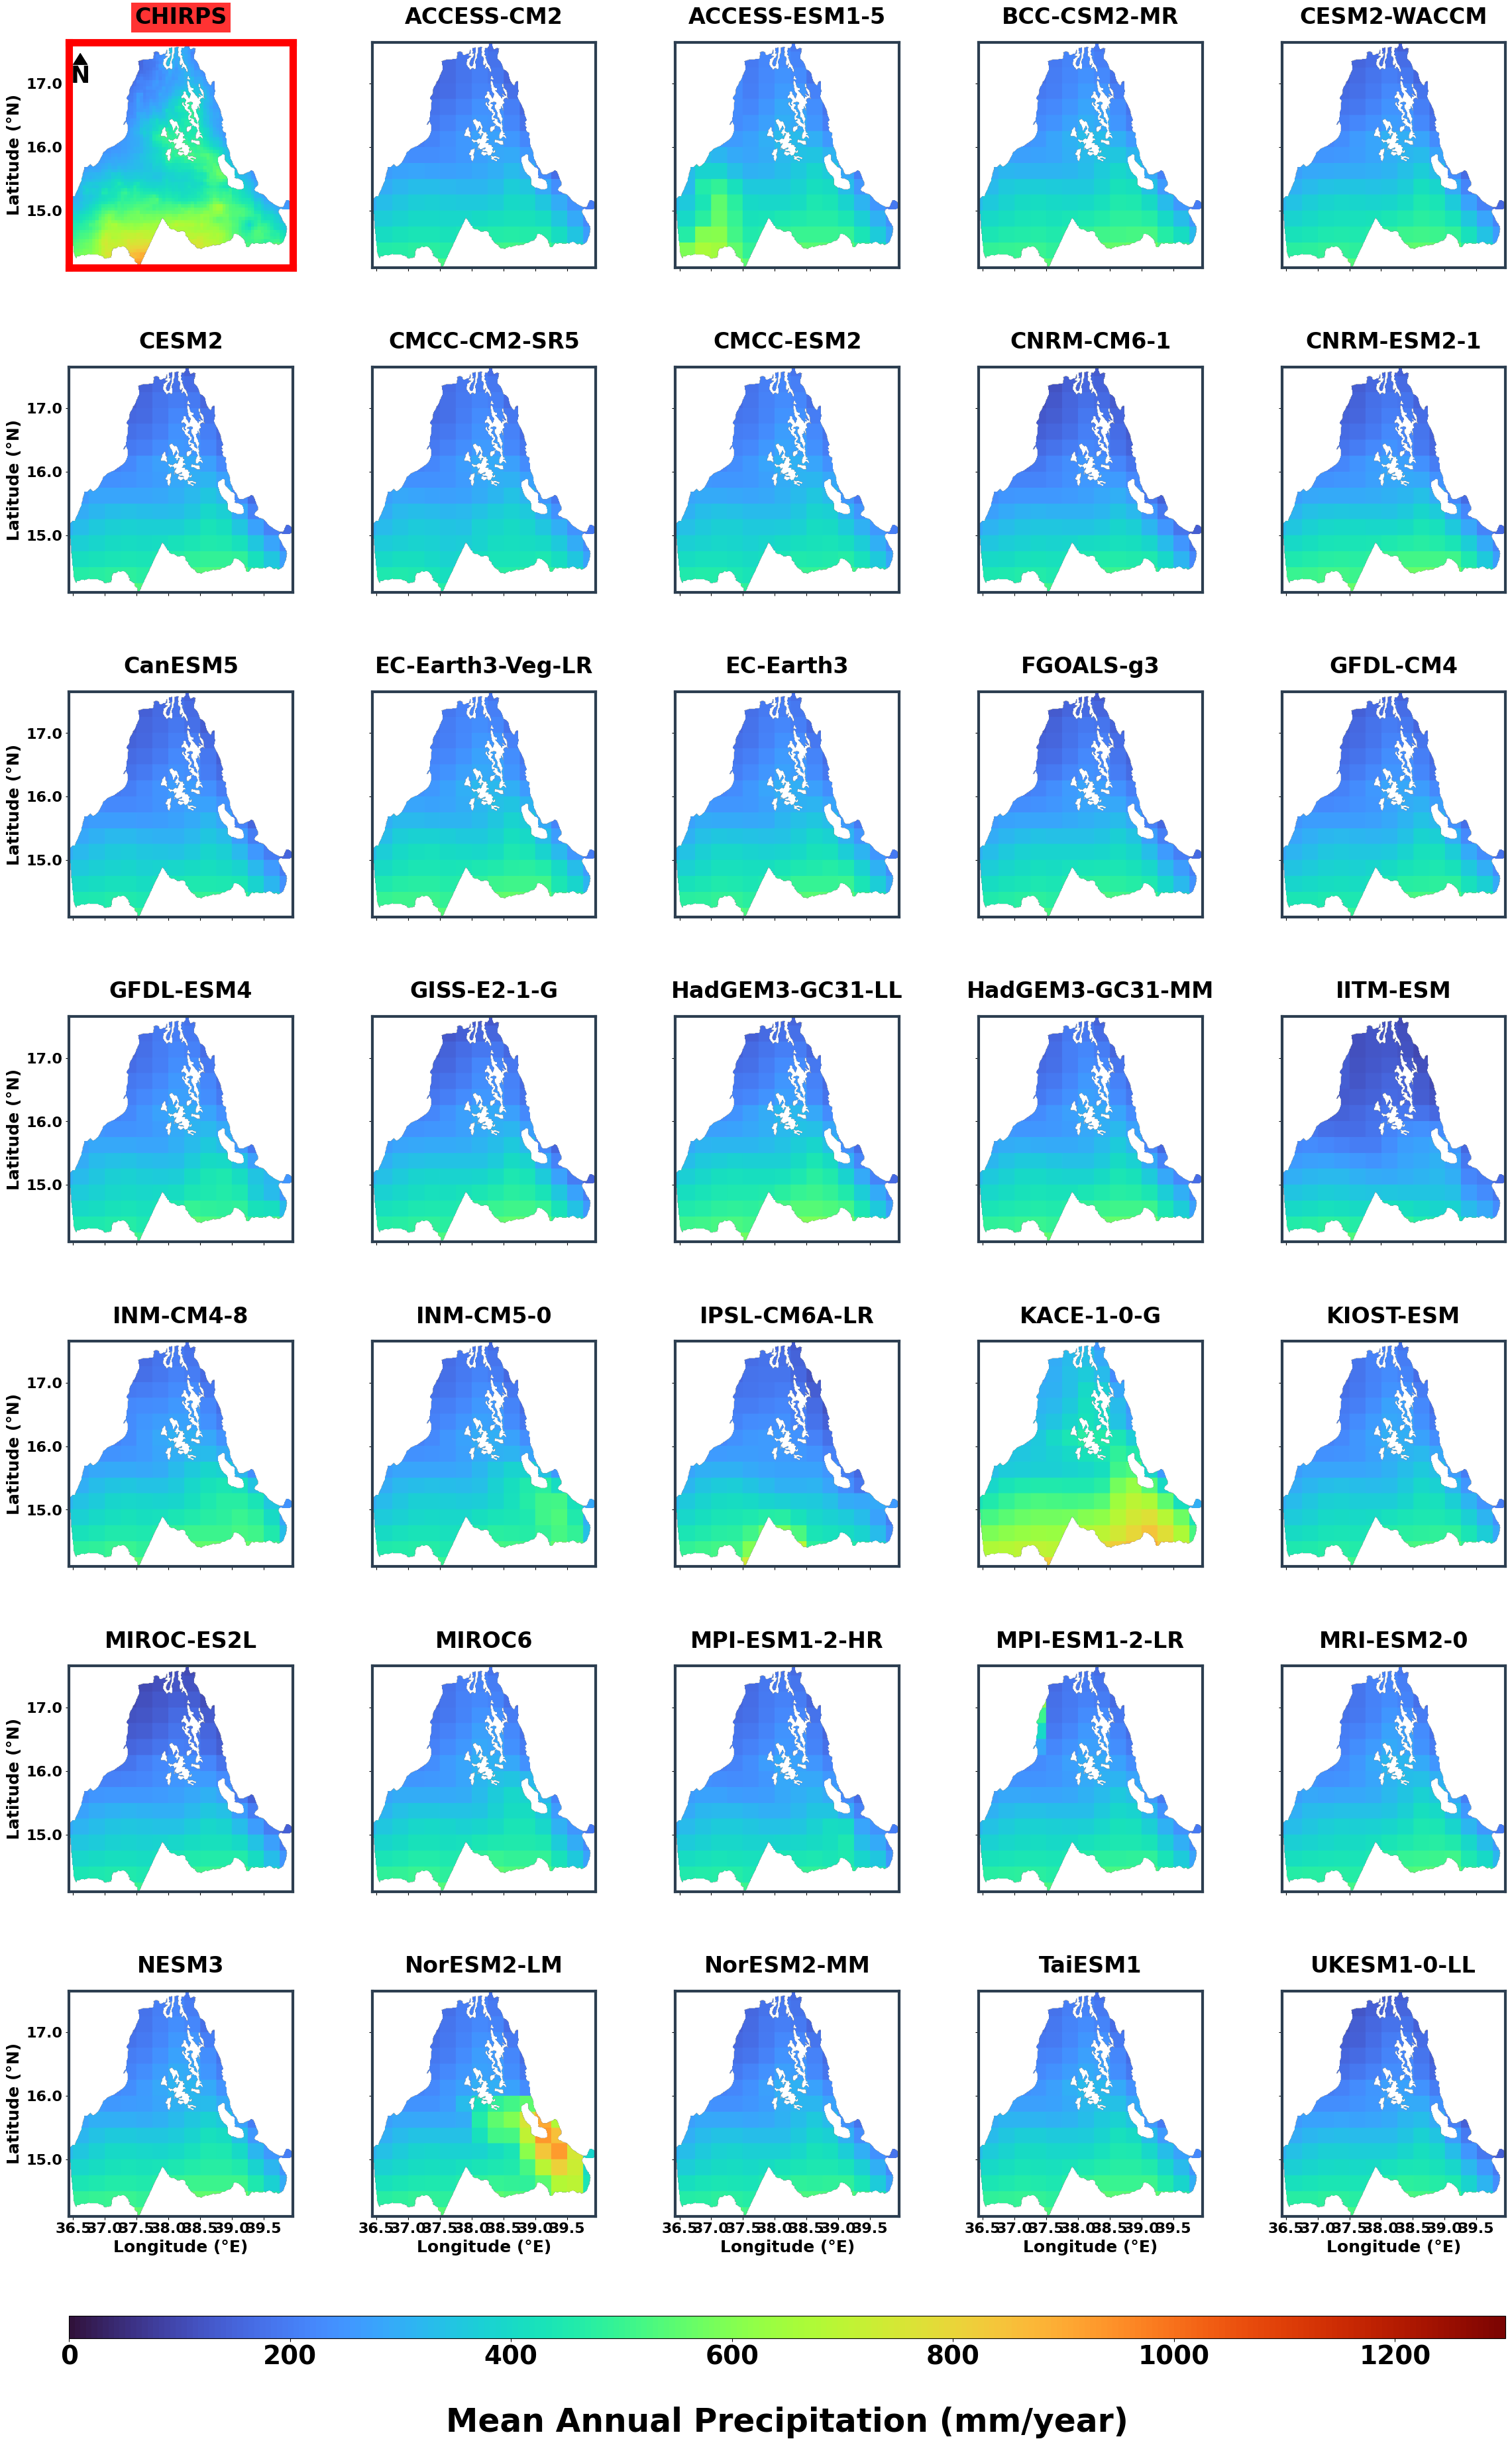

In [ ]:
### Script Seven ####
### Spatial Analysis and Mapping Design for Historical Time Slice ####

import os
import glob
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches

# 1. Paths
map_folder = '/content/MAPS'
roi_path = '/content/SELECTED_ZONES_WGS1984/SELECTED_ZONES_WGS1984.shp'
output_fig = 'CMIP6_Spatial_Masterpiece_600DPI.png'

# 2. Load ROI
roi = gpd.read_file(roi_path)

# 3. Get files - Ensure CHIRPS is first for the reference position
tif_files = glob.glob(os.path.join(map_folder, '*.tif'))
# Sort logic: Put CHIRPS at the start, then alphabetize the rest
chirps_file = [f for f in tif_files if "CHIRPS" in os.path.basename(f).upper()]
model_files = sorted([f for f in tif_files if "CHIRPS" not in os.path.basename(f).upper()])
final_files = chirps_file + model_files

# 4. Figure Setup
fig = plt.figure(figsize=(35, 45), facecolor='white')

# Grid setup with specialized padding
grid = ImageGrid(fig, 111,
                 nrows_ncols=(7, 5),
                 axes_pad=(1.2, 1.5),
                 share_all=True,
                 cbar_location="bottom",
                 cbar_mode="single",
                 cbar_size="2%",
                 cbar_pad=1.5)

print("🎨 Creating the Spatial Masterpiece...")

# 5. Execution Loop
for i, (ax, tif_path) in enumerate(zip(grid, final_files)):
    with rasterio.open(tif_path) as src:
        # Masking and Cropping
        out_image, out_transform = mask(src, roi.geometry, crop=True)
        out_image = out_image[0]

        # Nan handling for sharp edges
        out_image = np.where((out_image == src.nodata) | (out_image <= 0), np.nan, out_image)

        model_name = os.path.basename(tif_path).replace('_Mean_Annual_Rainfall.tif', '').replace('.tif', '')

        # The Plot - Using 'turbo' for high dynamic range
        im = ax.imshow(out_image, cmap='turbo', vmin=0, vmax=1300,
                       extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

        # CUSTOM TITLE BOXING
        title_color = 'white' if i == 0 else 'black'
        bbox_color = 'red' if i == 0 else 'none'
        ax.set_title(f"{model_name}", fontsize=24, fontweight='bold',
                     pad=20, bbox=dict(facecolor=bbox_color, edgecolor='none', alpha=0.8) if i==0 else None)

        # COORDINATES - Only on periphery for a clean look
        if i % 5 == 0:
            ax.set_ylabel('Latitude (°N)', fontsize=18, fontweight='bold')
            ax.tick_params(axis='y', labelsize=16, labelleft=True)
        if i >= 30:
            ax.set_xlabel('Longitude (°E)', fontsize=18, fontweight='bold')
            ax.tick_params(axis='x', labelsize=16, labelbottom=True)

        # FORMATTING TICKS
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontweight('bold')

        # FRAME DESIGN
        is_chirps = "CHIRPS" in model_name.upper()
        spine_color = 'red' if is_chirps else '#2C3E50'
        spine_width = 8 if is_chirps else 3

        for spine in ax.spines.values():
            spine.set_edgecolor(spine_color)
            spine.set_linewidth(spine_width)
            spine.set_visible(True)

        # ADD NORTH ARROW (Only on the first panel to keep it tidy)
        if i == 0:
            x, y, arrow_length = 0.05, 0.95, 0.1
            ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
                        arrowprops=dict(facecolor='black', width=5, headwidth=15),
                        ha='center', va='center', fontsize=25, fontweight='bold',
                        xycoords='axes fraction')

# 6. MASTER HORIZONTAL COLORBAR
cb = grid.cbar_axes[0].colorbar(im)
cb.set_label('Mean Annual Precipitation (mm/year)', fontsize=35, fontweight='bold', labelpad=40)
cb.ax.tick_params(labelsize=28)
for t in cb.ax.get_yticklabels():
    t.set_weight('bold')


plt.savefig(output_fig, dpi=600, bbox_inches='tight', facecolor='white')
print(f"✅ Masterpiece saved as {output_fig}")
plt.show()

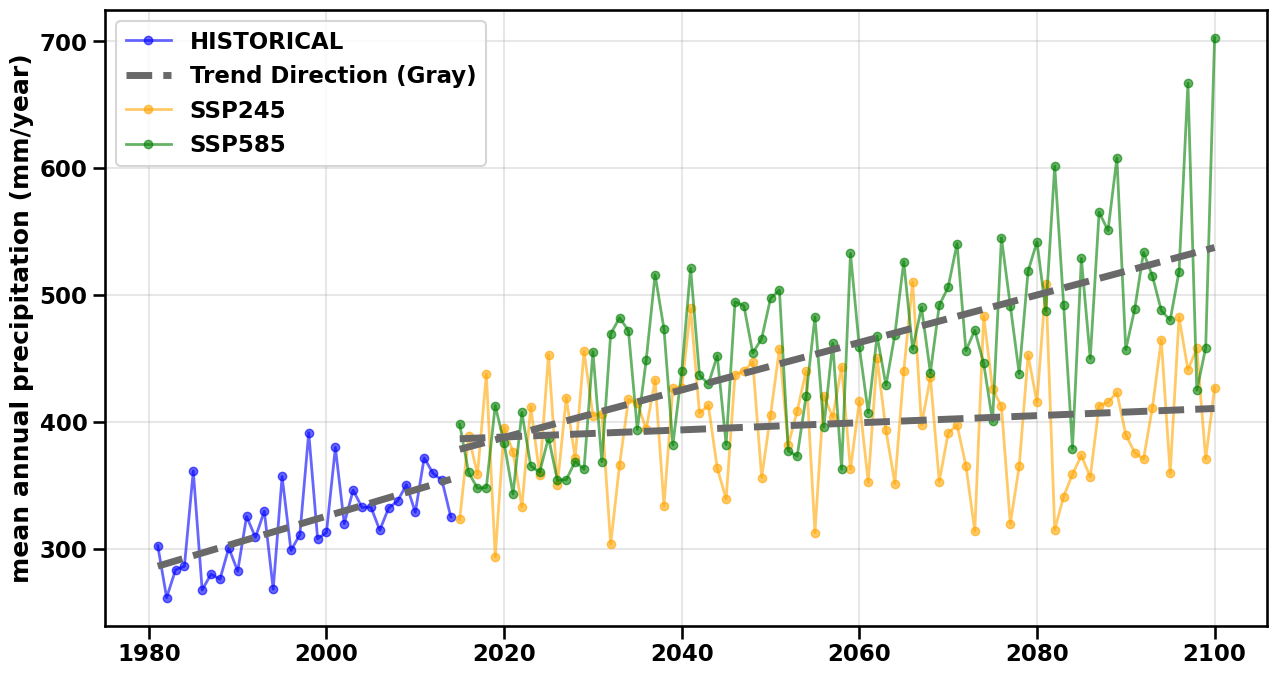

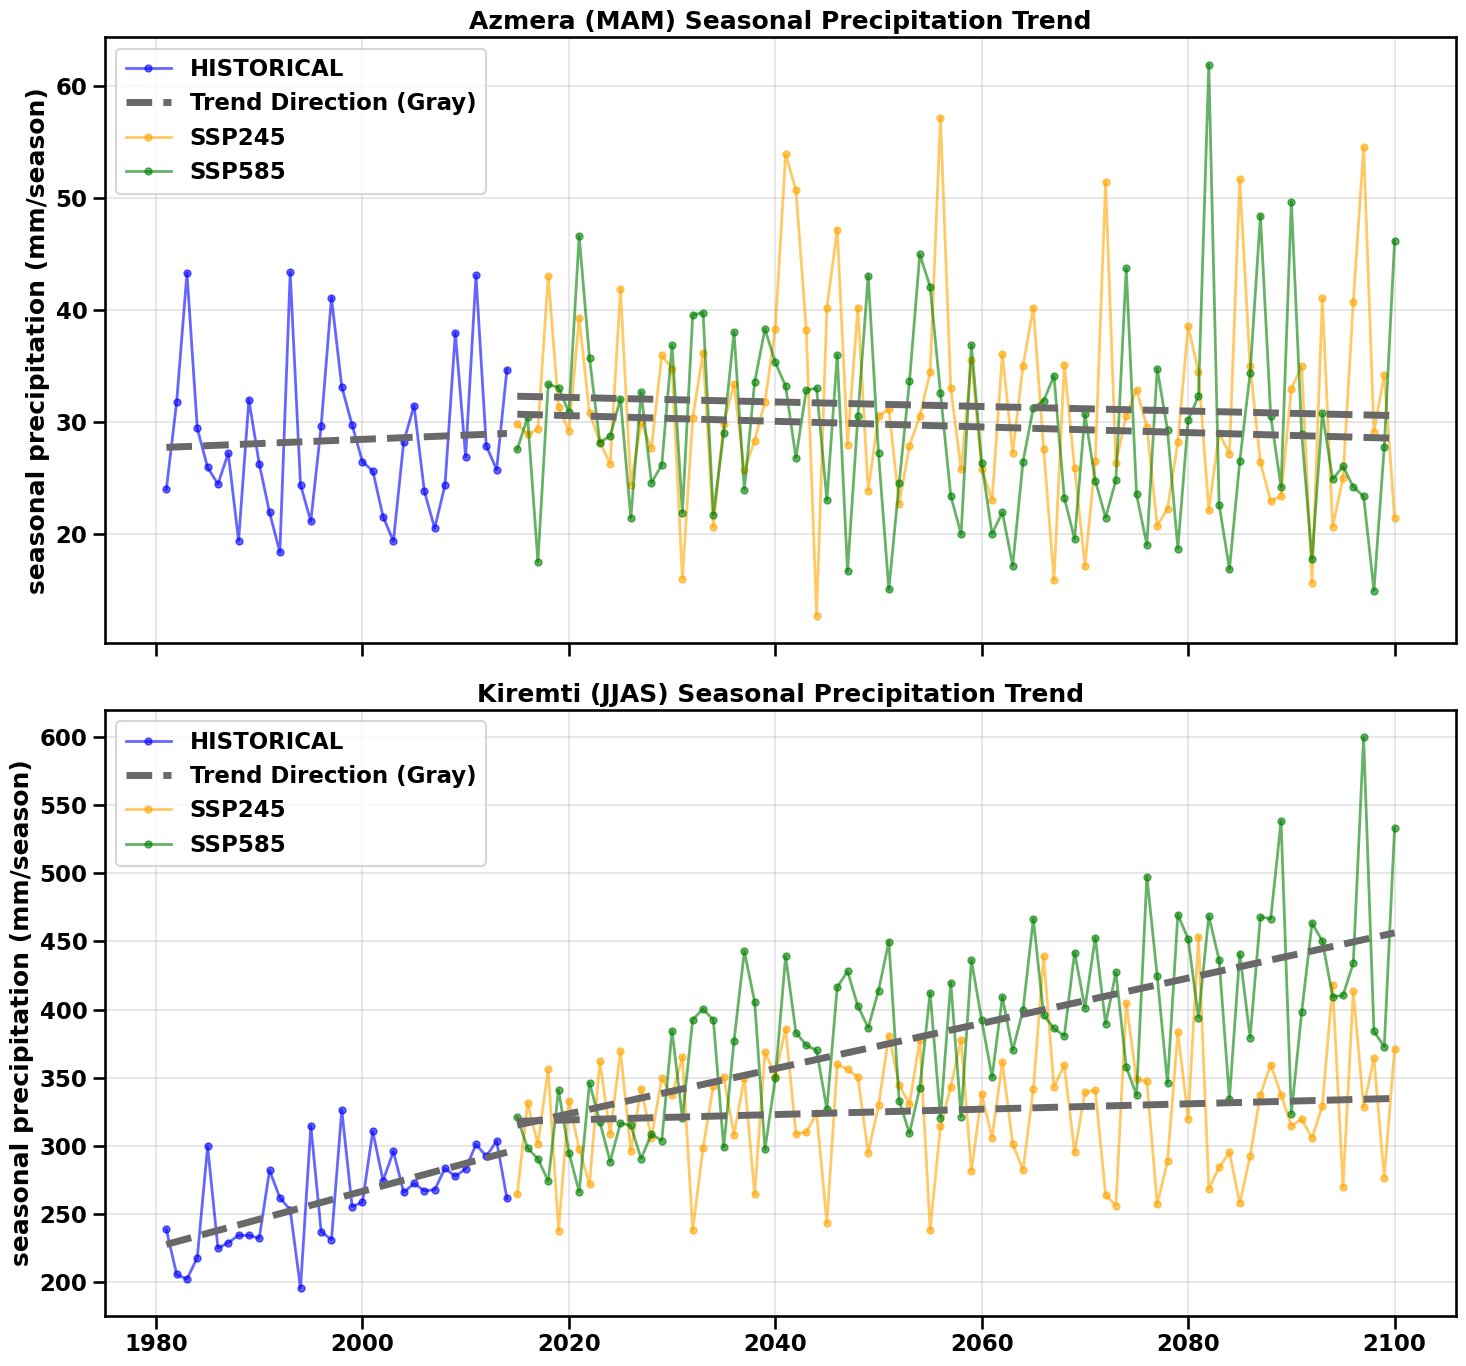

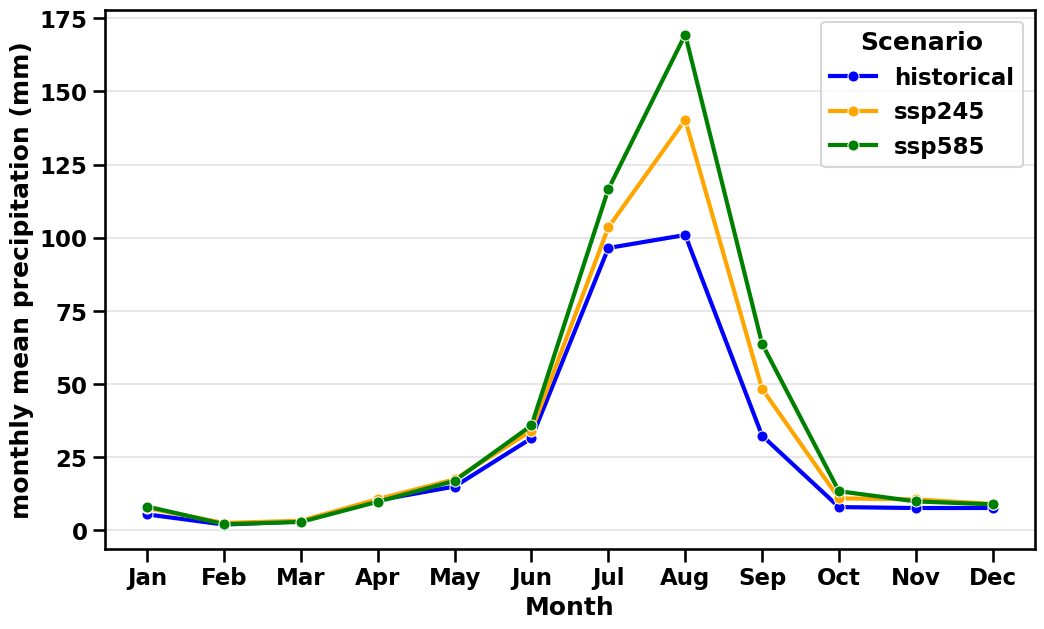

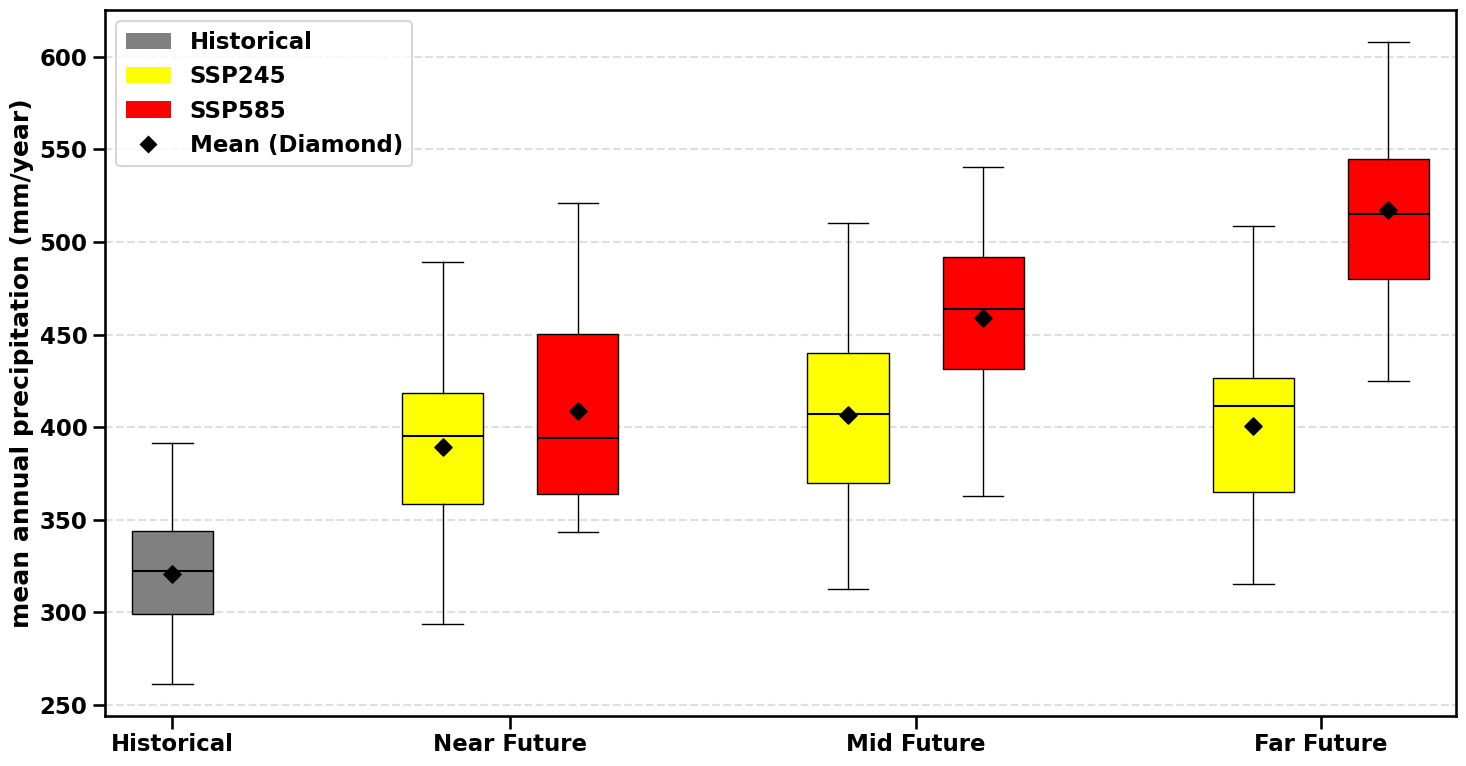

In [ ]:
### Script Eight ####
### Trend Analysis for the Historical Time Slice ####

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.patches import Patch

# 1. Load and Merge
hist_df = pd.read_csv('/content/TOP_10/CMIP6_Eritrea_NEW_Top10_Historical_1981_2014.csv')
ssp245_df = pd.read_csv('/content/TOP_10/CMIP6_Eritrea_NEW_Top10_Future_SSP245_2015_2100.csv')
ssp585_df = pd.read_csv('/content/TOP_10/CMIP6_Eritrea_NEW_Top10_Future_SSP585_2015_2100.csv')

df = pd.concat([hist_df, ssp245_df, ssp585_df], ignore_index=True)

# 2. Statistical Prep
ens_mean = df.groupby(['Scenario', 'Year', 'Month'])['Precip_mm'].mean().reset_index()

def get_eritrea_season(m):
    if m in [3, 4, 5]: return 'Azmera (MAM)'
    if m in [6, 7, 8, 9]: return 'Kiremti (JJAS)'
    return 'Dry'

def assign_slice(y):
    if 1981 <= y <= 2014: return 'Historical'
    if 2015 <= y <= 2045: return 'Near Future'
    if 2046 <= y <= 2075: return 'Mid Future'
    if 2076 <= y <= 2100: return 'Far Future'
    return None

ens_mean['Season'] = ens_mean['Month'].apply(get_eritrea_season)
ens_mean['TimeSlice'] = ens_mean['Year'].apply(assign_slice)

# Formatting
sns.set_context("talk")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
scenario_palette = {'historical': 'blue', 'ssp245': 'orange', 'ssp585': 'green'}

# Helper Function for Heavy Trendlines
def add_heavy_trendline(x, y, ax, label_needed=False):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    line = slope * x + intercept
    label = "Trend Direction (Gray)" if label_needed else ""
    ax.plot(x, line, color='#696969', linestyle='--', lw=5, alpha=1.0, label=label, zorder=10)

# =========================================================
# Plot 1: ANNUAL TOTAL (NO TITLE)
# =========================================================
annual = ens_mean.groupby(['Scenario', 'Year'])['Precip_mm'].sum().reset_index()
plt.figure(figsize=(15, 8))
first_trend = True
for scn, color in scenario_palette.items():
    subset = annual[annual['Scenario'] == scn]
    if not subset.empty:
        plt.plot(subset['Year'], subset['Precip_mm'], color=color, marker='o', markersize=6, lw=2, label=scn.upper(), alpha=0.6)
        add_heavy_trendline(subset['Year'], subset['Precip_mm'], plt.gca(), label_needed=first_trend)
        first_trend = False

# No title as requested
plt.ylabel('mean annual precipitation (mm/year)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.savefig('Eritrea_Annual_Final.png', dpi=650, bbox_inches='tight')

# =========================================================
# Plot 2: SEASONAL TRENDS (WITH TITLE)
# =========================================================
seasonal = ens_mean[ens_mean['Season'] != 'Dry'].groupby(['Scenario', 'Year', 'Season'])['Precip_mm'].sum().reset_index()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)
for ax, seas in zip([ax1, ax2], ['Azmera (MAM)', 'Kiremti (JJAS)']):
    first_trend = True
    for scn, color in scenario_palette.items():
        subset = seasonal[(seasonal['Season'] == seas) & (seasonal['Scenario'] == scn)]
        if not subset.empty:
            ax.plot(subset['Year'], subset['Precip_mm'], color=color, marker='o', markersize=5, lw=2, label=scn.upper(), alpha=0.6)
            add_heavy_trendline(subset['Year'], subset['Precip_mm'], ax, label_needed=first_trend)
            first_trend = False
    ax.set_title(f'{seas} Seasonal Precipitation Trend', fontweight='bold', fontsize=18)
    ax.set_ylabel('seasonal precipitation (mm/season)') # Appropriate seasonal label
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('Eritrea_Seasonal_Final.png', dpi=650, bbox_inches='tight')

# =========================================================
# Plot 3: MONTHLY CLIMATOLOGY (NO TITLE)
# =========================================================
climatology = ens_mean.groupby(['Scenario', 'Month'])['Precip_mm'].mean().reset_index()
plt.figure(figsize=(12, 7))
sns.lineplot(data=climatology, x='Month', y='Precip_mm', hue='Scenario', marker='o', markersize=8, lw=3, palette=scenario_palette)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
# No title as requested
plt.ylabel('monthly mean precipitation (mm)')
plt.grid(True, axis='y', alpha=0.3)
plt.savefig('Eritrea_Monthly_Climatology.png', dpi=650, bbox_inches='tight')

# =========================================================
# Plot 4: BOXPLOT (NO TITLE + MANUAL SPACING)
# =========================================================
boxplot_data_agg = ens_mean.groupby(['Scenario', 'Year', 'TimeSlice'])['Precip_mm'].sum().reset_index()

time_slices = ['Historical', 'Near Future', 'Mid Future', 'Far Future']
box_data, positions, colors, mean_values, mean_positions = [], [], [], [], []
pos_counter = 1

for ts in time_slices:
    scenarios_to_plot = ['historical', 'ssp245', 'ssp585']
    for sc in scenarios_to_plot:
        subset = boxplot_data_agg[(boxplot_data_agg['TimeSlice']==ts) & (boxplot_data_agg['Scenario']==sc)]['Precip_mm'].values
        if len(subset) > 0:
            box_data.append(subset)
            positions.append(pos_counter)
            if sc == 'historical': colors.append('gray')
            elif sc == 'ssp245': colors.append('yellow')
            else: colors.append('red')
            mean_values.append(np.mean(subset))
            mean_positions.append(pos_counter)
            pos_counter += 1
    pos_counter += 1 # Force physical gap between time slices

plt.figure(figsize=(15, 8))
bp = plt.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                 showfliers=False, medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.scatter(mean_positions, mean_values, marker='D', s=70, color='black', zorder=5)

new_xticks = []
for i, ts in enumerate(time_slices):
    group_pos = [p for p, d in zip(positions, box_data) if ts in boxplot_data_agg[boxplot_data_agg['Precip_mm'].isin(d)]['TimeSlice'].values]
    if group_pos: new_xticks.append(np.mean(group_pos))

plt.xticks(new_xticks, time_slices, fontweight='bold')
# No title as requested
plt.ylabel("mean annual precipitation (mm/year)", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='gray', label='Historical'),
    Patch(facecolor='yellow', label='SSP245'),
    Patch(facecolor='red', label='SSP585'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='black', markersize=10, label='Mean (Diamond)')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('Eritrea_Boxplot_Final.png', dpi=1200, bbox_inches='tight')
plt.show()

🚀 Synthesizing Ensemble Masterpiece...
✅ Ensemble Masterpiece saved as Top10_Ensemble_Masterpiece_1200DPI.png


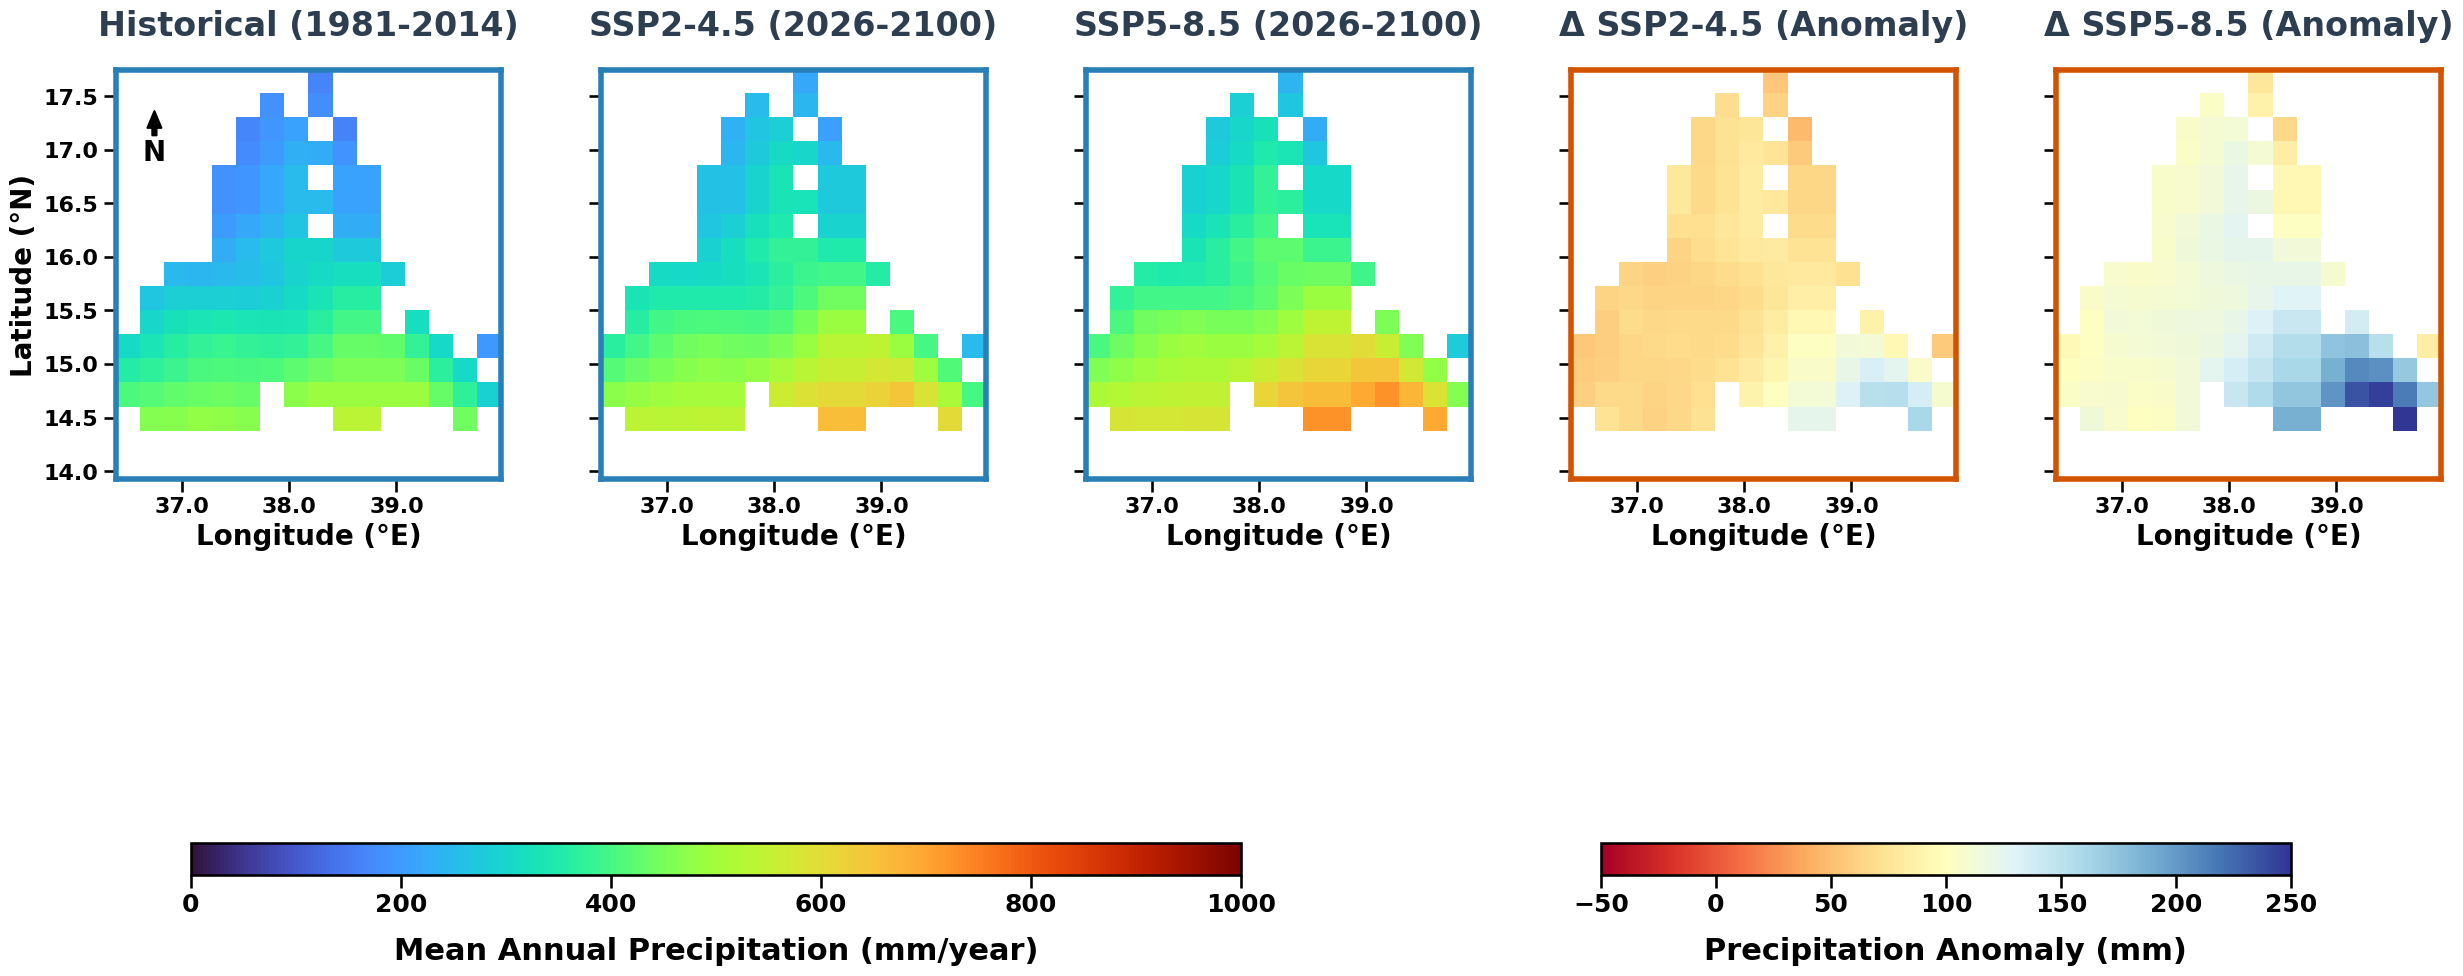

In [ ]:
### Script Nine ####
### Spatial Analysis and Mapping Design for the Future Time Slices ####

import os
import glob
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import FancyArrowPatch

# 1. Paths
map_folder = '/content/TOP_10_MAPS'
roi_path = '/content/SELECTED_ZONES_WGS1984/SELECTED_ZONES_WGS1984.shp'
output_fig = 'Top10_Ensemble_Masterpiece_1200DPI.png'

# 2. Load ROI
roi = gpd.read_file(roi_path)

# 3. File List
file_order = [
    'Top10_Hist_1981_2014_NEW.tif',
    'Top10_SSP245_Full_NEW.tif',
    'Top10_SSP585_Full_NEW.tif',
    'Top10_Change_SSP245_NEW.tif',
    'Top10_Change_SSP585_NEW.tif'
]

# 4. Figure Setup
fig = plt.figure(figsize=(30, 16), facecolor='white')
grid = ImageGrid(fig, 111,
                 nrows_ncols=(1, 5),
                 axes_pad=1.0,
                 share_all=True,
                 cbar_mode=None)

print("🚀 Synthesizing Ensemble Masterpiece...")

for i, (ax, filename) in enumerate(zip(grid, file_order)):
    tif_path = os.path.join(map_folder, filename)

    with rasterio.open(tif_path) as src:
        out_image, out_transform = mask(src, roi.geometry, crop=True)
        out_image = out_image[0]
        # Robust Clean-up
        out_image = np.where((out_image == src.nodata) | (out_image <= -999) | (out_image == 0), np.nan, out_image)

        # Scientific Naming
        name_map = {
            'Top10_Hist_1981_2014_NEW.tif': 'Historical (1981-2014)',
            'Top10_SSP245_Full_NEW.tif': 'SSP2-4.5 (2026-2100)',
            'Top10_SSP585_Full_NEW.tif': 'SSP5-8.5 (2026-2100)',
            'Top10_Change_SSP245_NEW.tif': 'Δ SSP2-4.5 (Anomaly)',
            'Top10_Change_SSP585_NEW.tif': 'Δ SSP5-8.5 (Anomaly)'
        }
        display_title = name_map.get(filename, "Model")

        # Color Logic
        if "Change" in filename:
            cmap = 'RdYlBu' # Divergent for change
            vmin, vmax = -50, 250
        else:
            cmap = 'turbo'  # Sequential for absolute
            vmin, vmax = 0, 1000

        # Plot
        im = ax.imshow(out_image, cmap=cmap, vmin=vmin, vmax=vmax,
                       extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])

        # Formatting
        ax.set_title(display_title, fontsize=24, fontweight='bold', pad=25, color='#2c3e50')

        # Coordinates - Periphery Logic
        if i == 0:
            ax.set_ylabel('Latitude (°N)', fontsize=20, fontweight='bold')
            ax.tick_params(axis='y', labelsize=16, labelleft=True)
            # Add North Arrow only on the first panel
            ax.annotate('N', xy=(0.1, 0.9), xytext=(0.1, 0.8),
                        arrowprops=dict(facecolor='black', width=3, headwidth=10),
                        ha='center', va='center', fontsize=20, fontweight='bold',
                        xycoords='axes fraction')
        else:
            ax.tick_params(axis='y', labelleft=False)

        ax.set_xlabel('Longitude (°E)', fontsize=20, fontweight='bold')
        ax.tick_params(axis='x', labelsize=16, labelbottom=True)

        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # Bold tick labels
        for label in (ax.get_xticklabels() + ax.get_yticklabels()):
            label.set_fontweight('bold')

        # Frame Aesthetics
        spine_color = '#d35400' if "Change" in filename else '#2980b9'
        for spine in ax.spines.values():
            spine.set_edgecolor(spine_color)
            spine.set_linewidth(4)

# --- 5. PREMIUM SEGMENTED COLORBARS ---
# Colorbar 1: Climatology (Under first 3 maps)
cax1 = fig.add_axes([0.15, 0.12, 0.35, 0.02])
cb1 = fig.colorbar(grid[0].get_images()[0], cax=cax1, orientation='horizontal')
cb1.set_label('Mean Annual Precipitation (mm/year)', fontsize=22, fontweight='bold', labelpad=15)
cb1.ax.tick_params(labelsize=18)
for t in cb1.ax.get_xticklabels(): t.set_fontweight('bold')

# Colorbar 2: Anomaly (Under last 2 maps)
cax2 = fig.add_axes([0.62, 0.12, 0.23, 0.02])
cb2 = fig.colorbar(grid[4].get_images()[0], cax=cax2, orientation='horizontal')
cb2.set_label('Precipitation Anomaly (mm)', fontsize=22, fontweight='bold', labelpad=15)
cb2.ax.tick_params(labelsize=18)
for t in cb2.ax.get_xticklabels(): t.set_fontweight('bold')


plt.savefig(output_fig, dpi=1200, bbox_inches='tight', facecolor='white')
print(f"✅ Ensemble Masterpiece saved as {output_fig}")
plt.show()

Processing Ensemble Data...


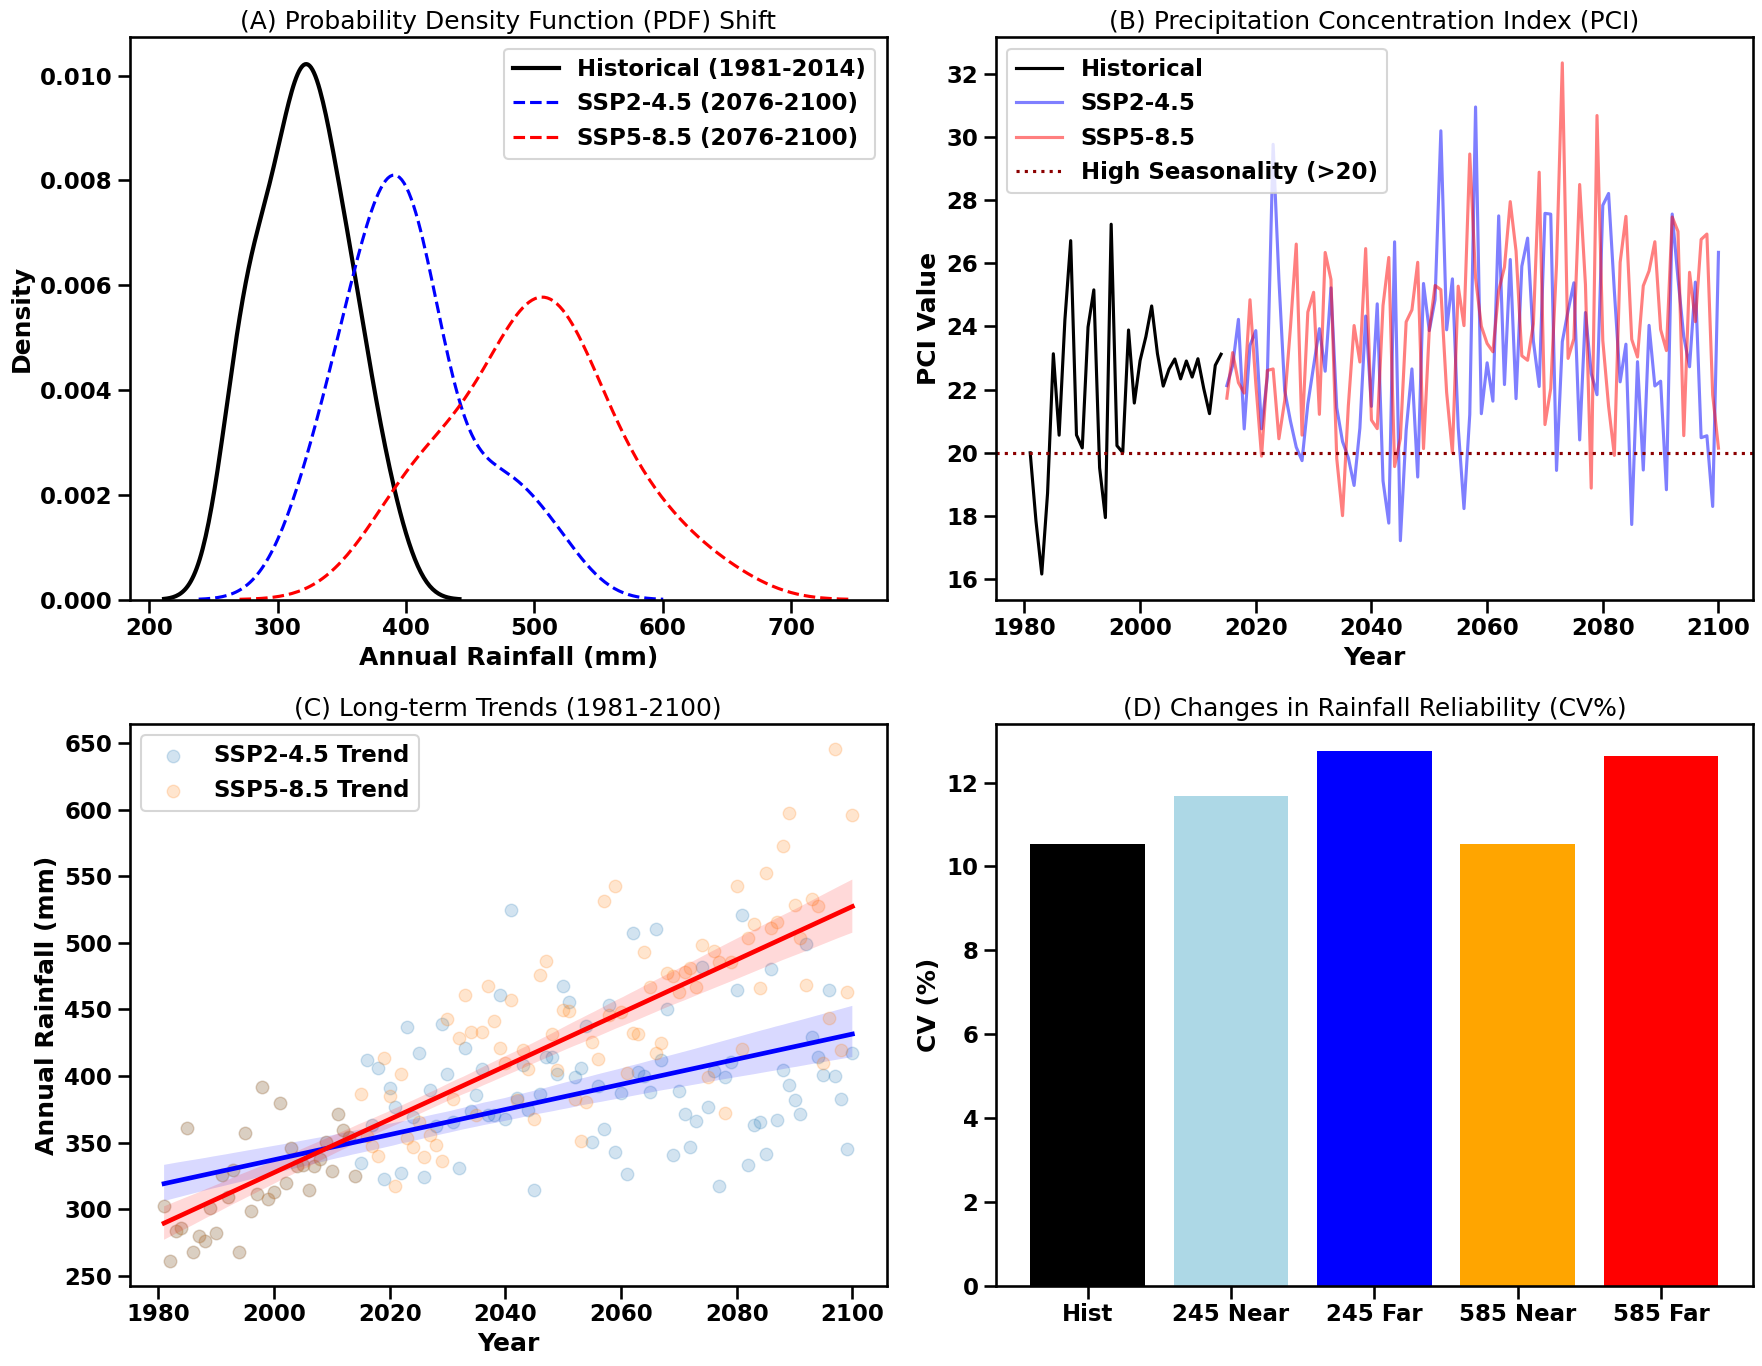

In [ ]:
### Script Ten ####
### Validation Analysis ####

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# 1. SETUP PATHS
paths = {
    'Historical': '/content/TOP_10/CMIP6_Eritrea_NEW_Top10_Historical_1981_2014.csv',
    'SSP245': '/content/TOP_10/CMIP6_Eritrea_NEW_Top10_Future_SSP245_2015_2100.csv',
    'SSP585': '/content/TOP_10/CMIP6_Eritrea_NEW_Top10_Future_SSP585_2015_2100.csv'
}

output_folder = '/content/ADVANCED_ANALYSIS'
if not os.path.exists(output_folder): os.makedirs(output_folder)

# 2. DATA PROCESSING ENGINE
def get_mme_data(path):
    df = pd.read_csv(path)
    m_mean = df.groupby(['Year', 'Month'])['Precip_mm'].mean().reset_index()
    a_total = m_mean.groupby('Year')['Precip_mm'].sum().reset_index()
    return m_mean, a_total

print("Processing Ensemble Data...")
hist_m, hist_a = get_mme_data(paths['Historical'])
s245_m, s245_a = get_mme_data(paths['SSP245'])
s585_m, s585_a = get_mme_data(paths['SSP585'])

# Helpers
full_245 = pd.concat([hist_a, s245_a])
full_585 = pd.concat([hist_a, s585_a])
def get_cv(series): return (series.std() / series.mean()) * 100
def calc_pci(df_m):
    pci_list = []
    for yr in df_m['Year'].unique():
        p = df_m[df_m['Year'] == yr]['Precip_mm'].values
        if len(p) == 12:
            pci = (np.sum(p**2) / (np.sum(p)**2)) * 100
            pci_list.append({'Year': yr, 'PCI': pci})
    return pd.DataFrame(pci_list)

pci_h = calc_pci(hist_m); pci_245 = calc_pci(s245_m); pci_585 = calc_pci(s585_m)

# 3. CREATE 4-PANEL FIGURE
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
sns.set_context("talk")

# PANEL A: PDF SHIFT (Top Left)
ax0 = axes[0, 0]
sns.kdeplot(hist_a['Precip_mm'], label='Historical (1981-2014)', color='black', lw=3, ax=ax0)
sns.kdeplot(s245_a.query('Year>=2075')['Precip_mm'], label='SSP2-4.5 (2076-2100)', color='blue', ls='--', ax=ax0)
sns.kdeplot(s585_a.query('Year>=2075')['Precip_mm'], label='SSP5-8.5 (2076-2100)', color='red', ls='--', ax=ax0)
ax0.set_title('(A) Probability Density Function (PDF) Shift')
ax0.set_xlabel('Annual Rainfall (mm)'); ax0.set_ylabel('Density'); ax0.legend()

# PANEL B: PCI TREND (Top Right)
ax1 = axes[0, 1]
ax1.plot(pci_h['Year'], pci_h['PCI'], color='black', label='Historical')
ax1.plot(pci_245['Year'], pci_245['PCI'], color='blue', alpha=0.5, label='SSP2-4.5')
ax1.plot(pci_585['Year'], pci_585['PCI'], color='red', alpha=0.5, label='SSP5-8.5')
ax1.axhline(y=20, color='darkred', linestyle=':', label='High Seasonality (>20)')
ax1.set_title('(B) Precipitation Concentration Index (PCI)')
ax1.set_xlabel('Year'); ax1.set_ylabel('PCI Value'); ax1.legend()

# PANEL C: TREND REGRESSION (Bottom Left)
ax2 = axes[1, 0]
sns.regplot(data=full_245, x='Year', y='Precip_mm', scatter_kws={'alpha':0.2}, line_kws={'color':'blue'}, label='SSP2-4.5 Trend', ax=ax2)
sns.regplot(data=full_585, x='Year', y='Precip_mm', scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, label='SSP5-8.5 Trend', ax=ax2)
ax2.set_title('(C) Long-term Trends (1981-2100)')
ax2.set_xlabel('Year'); ax2.set_ylabel('Annual Rainfall (mm)'); ax2.legend()

# PANEL D: CV BAR CHART (Bottom Right)
ax3 = axes[1, 1]
cv_vals = [
    get_cv(hist_a['Precip_mm']),
    get_cv(s245_a.query('2026<=Year<=2050')['Precip_mm']),
    get_cv(s245_a.query('2076<=Year<=2100')['Precip_mm']),
    get_cv(s585_a.query('2026<=Year<=2050')['Precip_mm']),
    get_cv(s585_a.query('2076<=Year<=2100')['Precip_mm'])
]
labels = ['Hist', '245 Near', '245 Far', '585 Near', '585 Far']
ax3.bar(labels, cv_vals, color=['black', 'lightblue', 'blue', 'orange', 'red'])
ax3.set_title('(D) Changes in Rainfall Reliability (CV%)')
ax3.set_ylabel('CV (%)')

plt.tight_layout()
plt.savefig(f'{output_folder}/Figure_Panel_Final.png', dpi=300)
plt.show()